# Machine Learning Essentials SS25 - Exercise Sheet 7

## Instructions
- `TODO`'s indicate where you need to complete the implementations.
- You may use external resources, but <b>write your own solutions</b>.
- Provide concise, but comprehensible comments to explain what your code does.
- Code that's unnecessarily extensive and/or not well commented will not be scored.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import dok_matrix, coo_matrix, csc_matrix
from scipy.sparse.linalg import lsqr

DATA_DIR = "data/"  # Change this to your data directory

## Task 1


In [2]:
# Discrete Radon Transform. Compute all the indices correctly is a bit demanding.
def construct_X(M, alphas, Np=None):
    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))
    
    D = M * M
    No = len(alphas)
    N = No * Np
    
    ja, jb = np.meshgrid(np.arange(M), np.arange(M), indexing='ij')
    """
    !! Move the origin to the center of the pixel grid.
    Why is it important?
    Our goal is to project the pixel centers onto the sensor lines,
    to ease the formulation of the projection matrix, we must make
    sure the sensor line crosses the origin.
    """
    C = np.stack([(ja - (M-1)/2).flatten(), (jb - (M-1)/2).flatten()])
    j_indices_all = (ja + M * jb).flatten()

    max_nonzero = 2 * D * No
    i_indices = np.zeros(max_nonzero, dtype=np.int32)
    j_indices = np.zeros(max_nonzero, dtype=np.int32)
    weights = np.zeros(max_nonzero, dtype=np.float32)
    
    idx = 0

    for io, alpha in enumerate(alphas):
        theta = np.deg2rad(alpha)
        
        n = np.array([np.cos(theta), -np.sin(theta)])
        
        # Project pixel centers onto sensor axis
        p = n @ C
        
        p_bin = p + (Np-1)/2
         
        # One sensor cell is contributed by two pixel centers
        ip0 = np.floor(p_bin).astype(int)
        ip1 = ip0 + 1

        # Compute weights
        w1 = p_bin - ip0
        w0 = 1.0 - w1

        # Filter valid sensor bins (Projected only into [0, Np - 1])
        valid0 = (ip0 >= 0) & (ip0 < Np)
        valid1 = (ip1 >= 0) & (ip1 < Np)
        
        # i = ip + Np * io
        i0 = ip0[valid0] + Np * io
        i1 = ip1[valid1] + Np * io
        
        j0 = j_indices_all[valid0]
        j1 = j_indices_all[valid1]
        
        # Fill preallocated arrays
        i_indices[idx:idx+len(i0)] = i0
        j_indices[idx:idx+len(i0)] = j0
        weights[idx:idx+len(i0)] = w0[valid0]
        idx += len(i0)
        
        i_indices[idx:idx+len(i1)] = i1
        j_indices[idx:idx+len(i1)] = j1
        weights[idx:idx+len(i1)] = w1[valid1]
        idx += len(i1)

    i_indices = i_indices[:idx]
    j_indices = j_indices[:idx]
    weights = weights[:idx]
    # print(i_indices, j_indices, sep='\n')
    
    # Construct sparse matrix in COO format
    X = coo_matrix((weights, (i_indices, j_indices)), shape=(N, D), dtype=np.float32)
    return X

### Quick sanity check 


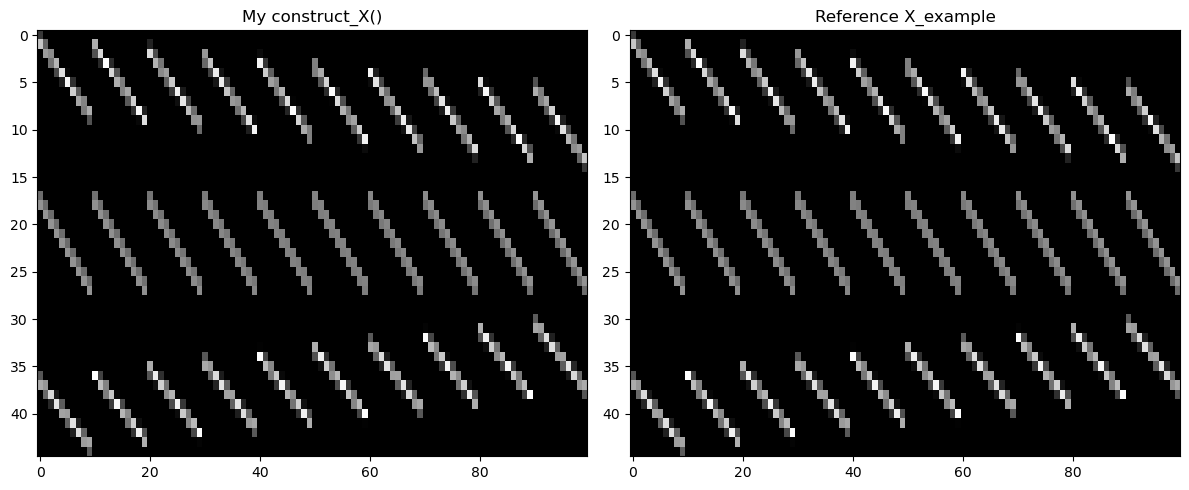

In [3]:
# TODO: Check if your image matches `X_example.npy` (Figure 2) up to mirror / transpose.
import matplotlib.pyplot as plt

X = construct_X(10, [-33, 1, 42], Np=15)
X_dense = X.todense()
X_ref = np.load(DATA_DIR + "X_example.npy")
X_ref_dense = X_ref

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_dense, cmap="gray", aspect='auto')
plt.title("My construct_X()")

plt.subplot(1, 2, 2)
plt.imshow(X_ref_dense, cmap="gray", aspect='auto')
plt.title("Reference X_example")

plt.tight_layout()
plt.show()

## Task 2 – Reconstruct the tomogram

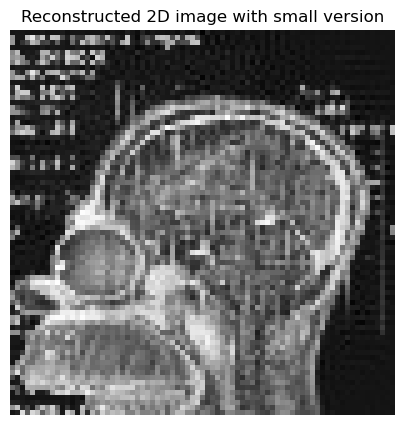

In [11]:
# TODO: Reconstruct the tomogram and plot it as a 2D image. Use scipy.sparse.linalg.lqsr() to make use of the sparsity of your matrix, see the instructions on the sheet.

alphas = np.load(DATA_DIR + 'alphas_77.npy')
y = np.load(DATA_DIR + 'y_77.npy')
M = 77
N_p = 109

X = construct_X(M, alphas, Np=N_p)
X_sparse = csc_matrix(X)

result = lsqr(X_sparse, y, atol=1e-05, btol=1e-05)
img = result[0].reshape((M, M))

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title('Reconstructed 2D image with small version')
plt.axis('off')
plt.show()

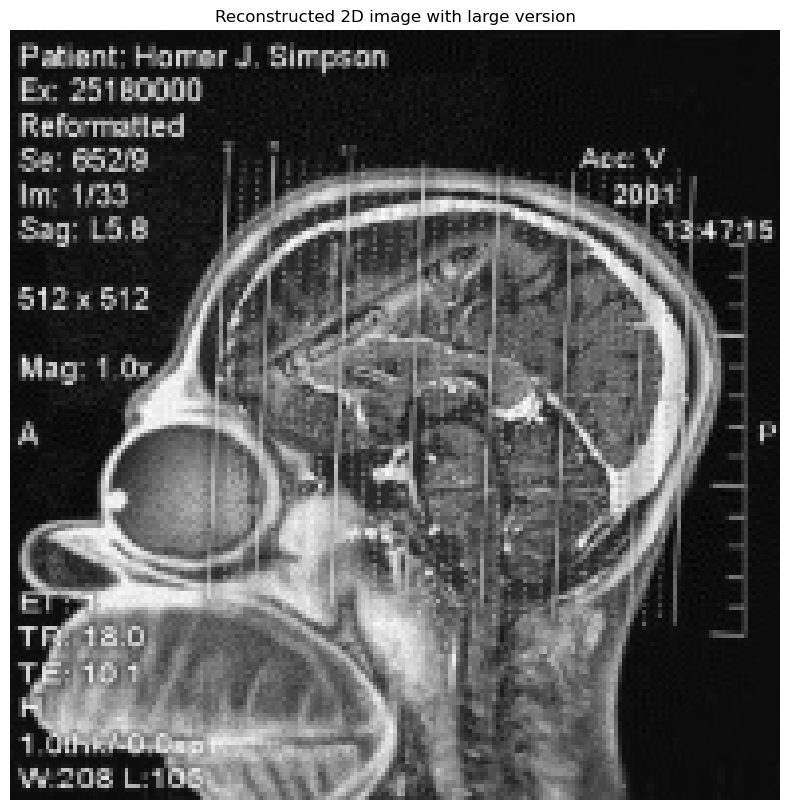

In [ ]:
alphas = np.load(DATA_DIR + 'alphas_195.npy')
y = np.load(DATA_DIR + 'y_195.npy')
M = 195
N_p = 275

X = construct_X(M, alphas, Np=N_p)
X_sparse = csc_matrix(X)

result = lsqr(X_sparse, y, atol=1e-08, btol=1e-08)
img = result[0].reshape((M, M))

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.title('Reconstructed 2D image with large version')
plt.axis('off')
plt.show()

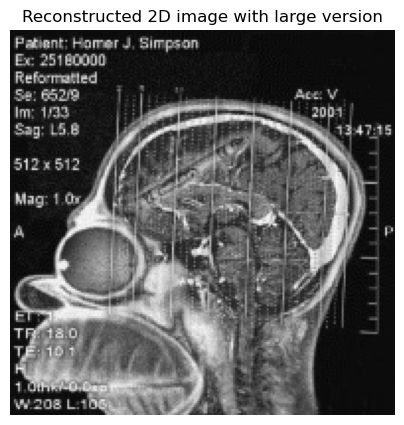

In [17]:
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title('Reconstructed 2D image with large version')
plt.axis('off')
plt.show()

### Diagnosis
TODO: describe the anomaly and suggest a treatment.

It semms like there is a hard long shape thing that is in the patient's brain, which should be what cause the headache. Therefore, a surgery should be implemented to take out the thing out of patient.

## Task 3 

In [20]:
def reconstruct_with_subset():
    # TODO: Reconstruct X using only a subset of projection angles.
    raise NotImplementedError

# TODO: Reduce the number of projectio angles in a sensible way and visualize how the reconstruction is affected by the number of angles used.

TODO: state the smallest number of projections that still resolves the pathology clearly enough to give a diagnosis and propose a treatment.
